# Classification - Churn problem

---

## Project Overview

**Objective:** Binary classification to distinguish between two types of early settlement:
- `SAN (1)` - client settled the contract early on their own initiative
- `SOL (0)` - client settled on agreed time

**Data:** Aggregated dataset - 1 row per client, merged from 4 source tables:
`BDOSSTOTAL` - `CRC` - `CredScore` - `FAMA`

---

## Notebook Structure

```
 0. SET UP                  Imports, constants, paths
 1. LOAD DATASET            Load aggregated client dataset (1 row per client)
 2. TRAIN / TEST SPLIT      Split once; drops 51 extra leaky features vs original  
                            (FEATURES ARE STILL BEING DEFINED)
 3. PREPROCESSING           Cleaning > Outliers > Imputation > OHE > Scaling
 4. FIT & TRANSFORM         fit_transform(X_train), transform(X_test)
 5. FEATURE SELECTION       Variance + correlation on X_train only 
                            (NOT COMPLETE)
 6. MODEL COMPARISON        cross_validate: LR, RF, HistGBM
 7. HYPERPARAMETER TUNING   RandomizedSearchCV on best model
 8. FINAL EVALUATION        predict(X_test_fs), ROC-AUC, report, Confusion Matrix
 9. FEATURE IMPORTANCE      Top-20 bar chart
```

---

## Anti-Leakage Rules

| Rule | Where enforced |
|---|---|
| `X_test` never influences any decision | Split in Section 2, only used in Section 8 |
| All statistics learned from train fold only | `fit_transform` only on `X_train` in Section 4 |
| Feature selection criteria computed on train only | Section 5 uses `X_train_df` exclusively |
| CV uses only `X_train_fs` | Sections 6 and 7 never touch `X_test_fs` |
| Post-settlement features removed | Section 2 drops 51 leaky features |


## 0. SET UP

In [1]:
# Standard library 
import sys
import os

# Add the project root to sys.path so that src.code modules are importable
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Load / save helpers
import src.code.io_utils as io_utils 

# Data wrangling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn - metrics
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_auc_score,
    classification_report,
)

# Scikit-learn - model selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline

# Scikit-learn - preprocessing
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import RobustScaler

# Scikit-learn - classifiers 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)

# Feature selection 
from sklearn.feature_selection import VarianceThreshold

#  Model inspection 
from sklearn.inspection import permutation_importance

#  Hyper-parameter distributions
from scipy.stats import loguniform, randint

# Custom pipeline transformers 
from src.code.class_pipeline_functions import (
    ClientDataCleaner,
    ClientOutlierHandler,
    ClientImputer,
    ClientFeatureEngineer,
    ClientOneHotEncoder,
)

# Global constants 
RANDOM_STATE = 42   # fixed seed for full reproducibility across runs

# Show all columns when inspecting DataFrames
pd.set_option('display.max_columns', None)

# Path to the Analytical Base Table produced by the data-preparation step
CLIENT_PATH = io_utils.output_path("prepared/abt.parquet")

## 1. Load Aggregation Dataset

In [2]:
# Load the aggregated ABT (1 row per client, expected 87 columns)
# The file was produced by notebooks 2a/2b and stored as parquet
client_data = io_utils.load(CLIENT_PATH)
client_data.head(3)

[LOAD] C:\Users\Rui\PycharmProjects\Business_Case_BNP\data\prepared/abt.parquet | shape: (148729, 87)


,CONTRIB,N_CONTRACTS,FIRST_DCREAT,LAST_DCREAT,LAST_DPOS,LAST_DATFIN,FIRST_D1FIN,MIN_DURDEG,MAX_DURDEG,MEDIAN_DURDEG,MIN_RANGPRO,MAX_RANGPRO,MEDIAN_RANGPRO,MIN_RANGCLI,MAX_RANGCLI,MEDIAN_RANGCLI,TOTAL_MTFIN,TOTAL_MTFINO,TOTAL_MENSALIDADE,TOTAL_CRD,TOTAL_SREC,TOTAL_RN,TOTAL_RD,LAST_RISK,MAX_RISKA,MIN_RESSO,MAX_RESSO,MEDIAN_RESSO,CSP,NBENF,EVER_SOL,N_SOL,EVER_SAN,N_SAN,EVER_RBT,N_RBT,LAST_OBS_DATE_SOL,LAST_OBS_DATE_SAN,LAST_OBS_DATE_RBT,IS_EARLY_SETTLER,IS_CHURN,MT_MENSAL_MIN,MT_MENSAL_MAX,MT_MENSAL_MEDIAN,COUNT_CL_MIN,COUNT_CL_MAX,COUNT_CL_MEDIAN,COUNT_AUTO_MIN,COUNT_AUTO_MAX,COUNT_AUTO_MEDIAN,COUNT_TOTAL_MIN,COUNT_TOTAL_MAX,COUNT_TOTAL_MEDIAN,MONTVENC_CL_MIN,MONTVENC_CL_MAX,MONTVENC_CL_MEDIAN,MONTVENC_CP_MIN,MONTVENC_CP_MAX,MONTVENC_CP_MEDIAN,MONTVENC_AUTO_MIN,MONTVENC_AUTO_MAX,MONTVENC_AUTO_MEDIAN,MONTVENC_HT_MIN,MONTVENC_HT_MAX,MONTVENC_HT_MEDIAN,DIVIDAS_CL_MIN,DIVIDAS_CL_MAX,DIVIDAS_CL_MEDIAN,DIVIDAS_CP_MIN,DIVIDAS_CP_MAX,DIVIDAS_CP_MEDIAN,DIVIDAS_AUTO_MIN,DIVIDAS_AUTO_MAX,DIVIDAS_AUTO_MEDIAN,DIVIDAS_HT_MIN,DIVIDAS_HT_MAX,DIVIDAS_HT_MEDIAN,kp_sqe_enc,ks_score_tier,ALLBD_N_Dossiers__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_IDADE_MEAN__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2,2024-06-25,2024-09-13,2025-11-17,2024-09-30,2024-06-27,84.0,120.0,102.0,3.0,13.0,8.0,19.0,19.0,19.0,24000.00,24000.00,438.761355,0.000,0.0,0.0,0.0,0,0.0,1513.466,1513.466,1513.466,80.0,0.0,0,0,1,2,0,0,NaT,2025-11-30,NaT,1,1,0.00,0.00,0.00,0.0,1.0,0.0,0.0,6.0,1.0,5.0,18.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,8000.00,0.00,1.65,3701.73,978.25,0.0,58633.86,15934.05,0.0,0.0,0.0,7.0,2.0,10.0,1.0,2.0,-438.9,10.0,S,F,33.0
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,1,2018-03-29,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.0,120.0,120.0,91.0,91.0,91.0,91.0,91.0,91.0,20000.00,20000.00,347.447280,8115.247,0.0,0.0,0.0,0,0.0,1113.258,1113.258,1113.258,80.0,1.0,0,0,0,0,0,0,NaT,NaT,NaT,0,0,538.67,547.45,545.07,4.0,12.0,4.0,0.0,0.0,0.0,10.0,30.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20308.94,69754.56,24983.22,5499.88,21274.83,7115.46,0.0,0.00,0.00,0.0,0.0,0.0,3.0,1.0,10.0,1.0,0.0,1166.9,10.0,C,P,52.0
2,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,2,2001-09-21,2001-09-27,2014-06-27,2001-10-04,2001-09-21,60.0,60.0,60.0,21.0,21.0,21.0,21.0,21.0,21.0,19453.11,19453.11,608.913796,0.000,0.0,2.0,24.0,-9223372036854775808,0.0,678.483,678.483,678.483,60.0,2.0,1,2,0,0,0,0,2024-03-31,NaT,NaT,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN


In [3]:
mask_pay = client_data[client_data[["EVER_SAN", "EVER_SOL", "EVER_RBT"]].eq(1).any(axis=1)]
mask_active = client_data[client_data["IS_CHURN"]==0]

In [16]:
mask_pay["IS_CHURN"].value_counts()

IS_CHURN
1    66322
0     1118
Name: count, dtype: int64

## 2. Train / Test Split

We define the target column and explicitly list every column that must be
**dropped before modelling**.  Each is dropped for one of four reasons:

1. **Target leakage** - features that encode partial or full knowledge of the outcome.
2. **Identifiers / metadata** - columns that carry no predictive signal.
3. **Raw date columns** - not suitable for tree-based models.
4. **Post-settlement features (Phases 1 & 2)** - features aggregated from observations
   using `'last'`/`'max'` that capture the state **after** settlement events, or
   temporal FAMA/CRC aggregations that span the post-settlement timeline.


In [18]:
# Define target and columns to exclude

target = 'IS_CHURN'          # churn label (related outcome)

drop_cols = [
    # Target and direct leakage
    target,                   # the label itself
    'EVER_SAN',               # leak: directly reveals SAN history
    'EVER_SOL',               # leak: directly reveals SOL history
    'N_SAN',                  # leak: count of SAN events
    'N_SOL',                  # leak: count of SOL events
    'EVER_RBT',               # leak: reveals RBT (reimbursement) events
    'N_RBT',                  # leak: count of RBT events
    'IS_SAN',                 # leak: binary SAN flag
    'IS_EARLY_SETTLER',  # 1 = SAN (early), 0 = SOL (on time)

    # Date columns with leakage risk
    'LAST_OBS_DATE_SOL',      # leak: date of last SOL observation
    'LAST_OBS_DATE_SAN',      # leak: date of last SAN observation
    'LAST_OBS_DATE_RBT',      # leak: date of last RBT observation

    # Phase 1 Leakage: Post-settlement BDOSS aggregations
    'TOTAL_CRD',              # residual credit at last obs -> 0 after payoff
    'TOTAL_SREC',             # recovery amount, only exists post-default
    'TOTAL_RN',               # nominal remaining, changes at settlement
    'TOTAL_RD',               # debt remaining, changes at settlement
    'LAST_RISK',              # risk score at last observation (post-settlement)
    'MAX_RISKA',              # max risk score (accumulates post-event info)
    'LAST_DPOS',              # date of last POS observation, approx settlement date
    'LAST_DATFIN',            # last contract end date, tied to settlement
    'FIRST_D1FIN',            # first contract end date, tied to settlement

    # Phase 2 Leakage: Temporal aggregations across client history (FAMA & CRC)
    # These use `.last()`, `.min()`, `.max()` over post-settlement data.
    'MT_MENSAL_MIN', 'MT_MENSAL_MAX',
    'COUNT_CL_MIN', 'COUNT_CL_MAX',
    'COUNT_AUTO_MIN', 'COUNT_AUTO_MAX',
    'COUNT_TOTAL_MIN', 'COUNT_TOTAL_MAX',
    'MONTVENC_CL_MIN', 'MONTVENC_CL_MAX',
    'MONTVENC_CP_MIN', 'MONTVENC_CP_MAX',
    'MONTVENC_AUTO_MIN', 'MONTVENC_AUTO_MAX',
    'MONTVENC_HT_MIN', 'MONTVENC_HT_MAX', 
    'DIVIDAS_CL_MIN', 'DIVIDAS_CL_MAX',
    'DIVIDAS_CP_MIN', 'DIVIDAS_CP_MAX',
    'DIVIDAS_AUTO_MIN', 'DIVIDAS_AUTO_MAX',
    'DIVIDAS_HT_MIN', 'DIVIDAS_HT_MAX',
# adicionar os dividas_total etc

    # Raw date columns (not model-ready)
    'FIRST_DCREAT',           # date: first contract creation
    'LAST_DCREAT',            # date: last contract creation

    # Client ID (not predictive, just an identifier)
    'CONTRIB'
]

# Drop columns (errors='ignore' handles cols absent in the data)
X = mask_pay.drop(columns=drop_cols, errors='ignore')
y = mask_pay[target]

# Sanity check: the target must be binary
assert y.nunique() == 2, (
    f"Expected a binary target, but found {y.nunique()} unique values: {y.unique()}"
)

print(f'All specified leaky features explicitly dropped. Remaining columns: {X.shape[1]}')

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,                  # preserve the SAN/SOL ratio in both sets
    random_state=RANDOM_STATE,
)

print(f'\nTrain : {X_train.shape} - Churn rate: {y_train.mean():.2%}')
print(f'Test  : {X_test.shape}  - Churn rate: {y_test.mean():.2%}')

# Cross-validation strategy
# 5-fold stratified CV keeps the class ratio stable across folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

All specified leaky features explicitly dropped. Remaining columns: 40

Train : (53952, 40) - Churn rate: 98.34%
Test  : (13488, 40)  - Churn rate: 98.34%


## 3. Build Preprocessing Pipeline

No model here - this pipeline only preprocesses the data.
The model is added later after feature selection.


In [5]:
# Assemble the preprocessing pipeline
# Each step is a custom sklearn transformer defined in class_pipeline_functions.py.
# They follow the fit/transform contract so that statistics are learned
# on training data only and applied consistently to test data.

preprocessing_pipe = Pipeline([

    # Step 1: Cleaning
    # Convert dtypes, remove unwanted columns, enforce numeric ranges.
    # LAST_RISK and MAX_RISKA are no longer present (dropped as leaky),
    # so numeric_ranges is empty.
    ('cleaning', ClientDataCleaner(
        datetime_cols  = [],
        cols_to_remove = [],
        numeric_ranges = {},
        verbose        = True,
    )),

    # Step 2: Outlier detection and neutralisation
    # Uses a multi-method voting approach (IQR + modified Z-score).
    # A value must be flagged by at least 2 methods to be set to NaN.
    # CSP is a discrete socio-professional code (10, 20, ..., 99);
    # it must NOT be treated as a continuous variable for outlier detection.
    ('outliers', ClientOutlierHandler(
        methods      = ('iqr', 'mod_z'),
        min_votes    = 2,
        iqr_k        = 1.5,
        exclude_cols = ['CSP'],
        verbose      = True,
    )),

    # Step 3: Imputation
    # Numeric: fill missing values with the median (robust to remaining outliers).
    # Categorical: fill with 'Unknown'.
    ('imputer', ClientImputer(
        numeric_strategy  = 'median',
        datetime_strategy = 'ffill', # doesn't matter because we have no datetime cols after dropping leaky features
        verbose           = True,
    )),

    # ClientFeatureEngineer is intentionally skipped here because
    # abt.parquet is already aggregated.

    # Step 4: One-Hot Encoding for categorical features
    # Encodes sdem_SITFAM, sdem_HABITAT, and CSP into dummy variables.
    ('encoder', ClientOneHotEncoder(
        cols=['sdem_SITFAM', 'sdem_HABITAT', 'CSP'],
        drop_first=False,
        verbose=True,
    )),

    # Step 5: Scaling
    # StandardScaler (z-score normalisation) on all numeric columns.
    ('ct', ColumnTransformer([
        ('num', RobustScaler(), make_column_selector(dtype_include='number'))
    ], remainder='passthrough', verbose_feature_names_out=False)),
])

print('Pipeline built successfully')

Pipeline built successfully


## 4. Fit & Transform

- `fit_transform` on `X_train`: pipeline learns all statistics from training data only
- `transform` on `X_test`: applies without learning anything new

**Never call `fit_transform` on `X_test`.**


In [6]:
# Fit on train, transform both 
# The pipeline learns all statistics (medians, IQR bounds, OHE categories,
# scaler means/stds) from X_train during fit_transform().
# X_test is only transformed - no information from it leaks into the pipeline.
X_train_processed = preprocessing_pipe.fit_transform(X_train, y_train)
X_test_processed  = preprocessing_pipe.transform(X_test)

# Retrieve feature names from the ColumnTransformer
feature_names = preprocessing_pipe.named_steps['ct'].get_feature_names_out()

# Convert numpy arrays back to DataFrames for convenience
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_processed,  columns=feature_names)

# Quick sanity checks
print(f'X_train processed : {X_train_df.shape}')
print(f'X_test  processed : {X_test_df.shape}')

remaining_nans = X_train_df.isna().sum().sum()
print(f'Any NaNs remaining: {remaining_nans}')

# Warn if any NaNs survived the pipeline (should be 0)
if remaining_nans > 0:
    print("WARNING: NaN values remain after preprocessing - check the pipeline!")

[ClientDataCleaner]
  Output shape     : (53952, 40)
  Columns removed  : —
  Dates converted  : —

[ClientOutlierHandler]
  Methods      : ('iqr', 'mod_z')  (min_votes=2)
  IQR k        : 1.5  |  Z threshold : 3.5
  Total flagged: 32113 cell(s) → set to NaN

    TOTAL_MTFINO                        4128 outlier(s)
    TOTAL_MTFIN                         4128 outlier(s)
    DIVIDAS_CP_MEDIAN                   3992 outlier(s)
    TOTAL_MENSALIDADE                   3639 outlier(s)
    MAX_RESSO                           2903 outlier(s)
    DIVIDAS_CL_MEDIAN                   2762 outlier(s)
    MEDIAN_RESSO                        2664 outlier(s)
    MIN_RESSO                           2611 outlier(s)
    ALLBD_N_Dossiers__N                 1677 outlier(s)
    ALLBD_N_events__N                   1677 outlier(s)
    COUNT_CL_MEDIAN                     330 outlier(s)
    MAX_DURDEG                          323 outlier(s)
    ALLBD_IDADE_MEAN__N                 290 outlier(s)
    COUNT_TOTAL

## 5. Feature Selection

Feature selection is applied on `X_train_df` only.
The same selected columns are then applied to `X_test_df`.

**No leakage here because:**
- All selection criteria (variance, correlation) are computed on `X_train_df`
- `X_test_df` is only filtered at the end using the mask learned from train


In [7]:
#  5a. Remove constant / quasi-constant features 
# VarianceThreshold(0.01) drops features whose variance is below 0.01.
# After StandardScaler most features have variance ≈ 1, so this threshold
# is intentionally very low — it only catches truly constant columns.
print(f"Initial features: {X_train_df.shape[1]}")

var_thresh = VarianceThreshold(threshold=0.01)
var_thresh.fit(X_train_df)

# Boolean mask of features that passed the variance filter
var_mask = var_thresh.get_support()
features_after_var = X_train_df.columns[var_mask].tolist()

# Report any removed features
removed_by_var = X_train_df.columns[~var_mask].tolist()
print(f"Features after VarianceThreshold (th=0.01): {len(features_after_var)}")
if removed_by_var:
    print(f"  Removed (near-zero variance): {removed_by_var}")

# Subset the training DF for the next step
X_train_var = X_train_df[features_after_var]

#  5b. Iterative correlation-based feature removal 
# Instead of dropping EVERY feature that has any partner above the
# threshold, we iteratively remove the feature with the MOST
# high-correlation partners.  This preserves maximum information.

CORR_THRESHOLD = 0.90
corr_matrix = X_train_var.corr().abs()

# Zero out the diagonal and lower triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = []
drop_reasons = {}   # feature  list of correlated partners that caused removal

while True:
    # Count how many high-corr partners each remaining feature has
    high_corr_counts = (upper > CORR_THRESHOLD).sum()
    max_count = high_corr_counts.max()

    if max_count == 0:
        break   # no more high correlations

    # Pick the feature with the most high-corr partners
    worst_feature = high_corr_counts.idxmax()

    # Record which partners triggered the drop (for audit trail)
    partners = upper.columns[upper[worst_feature] > CORR_THRESHOLD].tolist()
    partners += upper.index[upper.loc[:, worst_feature] > CORR_THRESHOLD].tolist() if worst_feature in upper.columns else []
    drop_reasons[worst_feature] = list(set(partners))

    to_drop.append(worst_feature)

    # Remove this feature from the correlation matrix entirely
    upper = upper.drop(index=worst_feature, columns=worst_feature)

print(f"\nHighly correlated features to drop (>{CORR_THRESHOLD}): {len(to_drop)}")

# Print pair-level audit trail
if to_drop:
    for feat in to_drop:
        partners_str = ", ".join(drop_reasons[feat][:5])
        extra = f" (+{len(drop_reasons[feat])-5} more)" if len(drop_reasons[feat]) > 5 else ""
        print(f"   {feat}   correlated with: {partners_str}{extra}")

#  5c. Build the final selected feature list 
selected_features = [f for f in features_after_var if f not in to_drop]
print(f"\nFeatures after selection: {len(selected_features)}")

# Apply the same mask to both train and test
X_train_fs = X_train_df[selected_features]
X_test_fs  = X_test_df[selected_features]

#  Sanity check: both sets must have identical columns 
assert list(X_train_fs.columns) == list(X_test_fs.columns), (
    "Train and test feature sets have different columns after selection!"
)
print(f" Train and test share the same {len(selected_features)} columns.")

Initial features: 88
Features after VarianceThreshold (th=0.01): 66
  Removed (near-zero variance): ['sdem_HABITAT_0', 'sdem_HABITAT_E', 'sdem_HABITAT_O', 'sdem_HABITAT_X', 'CSP_0.0', 'CSP_10.0', 'CSP_25.0', 'CSP_33.0', 'CSP_34.0', 'CSP_40.0', 'CSP_50.0', 'CSP_51.0', 'CSP_52.0', 'CSP_53.0', 'CSP_54.0', 'CSP_55.0', 'CSP_57.0', 'CSP_58.0', 'CSP_81.0', 'CSP_86.0', 'CSP_96.0', 'CSP_99.0']

Highly correlated features to drop (>0.9): 8
   MEDIAN_DURDEG   correlated with: MAX_DURDEG, MIN_DURDEG
   MEDIAN_RANGPRO   correlated with: MIN_RANGPRO, MAX_RANGPRO
   MEDIAN_RANGCLI   correlated with: MIN_RANGCLI, MAX_RANGCLI
   MEDIAN_RESSO   correlated with: MAX_RESSO, MIN_RESSO
   MAX_RANGCLI   correlated with: MIN_RANGCLI
   TOTAL_MTFINO   correlated with: TOTAL_MTFIN
   ALLBD_N_events__N   correlated with: ALLBD_N_Dossiers__N
   sdem_HABITAT_Unknown   correlated with: sdem_SITFAM_Unknown

Features after selection: 58
 Train and test share the same 58 columns.


## 6. Model Comparison

Quick baseline comparison across models using cross-validation on `X_train_fs`.
Pick the best baseline before investing time in hyperparameter tuning.

We include **train scores** alongside test scores so we can check for overfitting.


In [8]:
# Define baseline models with sensible defaults
models = {
    # Logistic Regression - linear baseline
    # max_iter=1000 to ensure convergence on a dataset of this size
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),

    # Random Forest - ensemble of decision trees (bagging)
    # n_estimators=100 is a good starting point; n_jobs=-1 parallelises
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    # HistGBM - histogram-based gradient boosting (fast, handles NaN natively)
    # max_iter=100 keeps baseline training fast
    'HistGBM': HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_iter=100,
    ),
}

# Cross-validate each model 
results = []
for name, model in models.items():
    print(f"Training {name}...")
    cv_res = cross_validate(
        model,
        X_train_fs,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        return_train_score=True,   # <-- also capture train-fold AUC
    )
    results.append({
        'Model': name,
        'Train ROC-AUC': cv_res['train_score'].mean(),
        'Val ROC-AUC':   cv_res['test_score'].mean(),
        'Std Val AUC':   cv_res['test_score'].std(),
    })

# Display results sorted by validation AUC
results_df = pd.DataFrame(results).sort_values(by='Val ROC-AUC', ascending=False)
display(results_df)

# Select the best baseline model for tuning 
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\nSelected {best_model_name} as the best baseline model.")

# Overfitting check
# A large gap between Train and Val AUC signals overfitting
for _, row in results_df.iterrows():
    gap = row['Train ROC-AUC'] - row['Val ROC-AUC']
    if gap > 0.05:
        print(f"CAUTION!  {row['Model']}: train-val gap = {gap:.4f} - possible overfitting")


Training Logistic Regression...
Training Random Forest...
Training HistGBM...


,Model,Train ROC-AUC,Val ROC-AUC,Std Val AUC
2,HistGBM,0.984619,0.911119,0.006090
1,Random Forest,1.000000,0.889017,0.009015
0,Logistic Regression,0.858806,0.847012,0.006427



Selected HistGBM as the best baseline model.
CAUTION!  HistGBM: train-val gap = 0.0735 - possible overfitting
CAUTION!  Random Forest: train-val gap = 0.1110 - possible overfitting


## 7. Hyperparameter Tuning

Run `RandomizedSearchCV` on the best model from Section 6.
Still using only `X_train_fs`. `X_test_fs` remains untouched.


In [9]:
# Define search spaces per model
print(f"Tuning {best_model_name}...")

if best_model_name == 'HistGBM':
    # learning_rate: controls step size per boosting round
    # max_iter: number of boosting rounds
    # max_depth: tree depth (complexity)
    # min_samples_leaf: regularisation
    # l2_regularization: L2 penalty on leaf values
    param_distributions = {
        'learning_rate':     loguniform(0.01, 0.2),
        'max_iter':          randint(100, 300),
        'max_depth':         randint(3, 10),
        'min_samples_leaf':  randint(10, 50),
        'l2_regularization': loguniform(1e-4, 10.0),
    }

elif best_model_name == 'Random Forest':
    # n_estimators: number of trees
    # max_depth: tree depth
    # min_samples_split: min samples to split a node
    # min_samples_leaf: min samples in a leaf
    param_distributions = {
        'n_estimators':      randint(100, 300),
        'max_depth':         randint(5, 20),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf':  randint(1, 10),
    }

else:  # Logistic Regression
    # C: inverse regularisation strength
    # solver: saga supports L1/L2; liblinear is faster for small datasets
    param_distributions = {
        'C':      loguniform(1e-3, 1e2),
        'solver': ['liblinear', 'saga'],
    }


# Run RandomizedSearchCV 
# n_iter=10 for a quick baseline; increase for production
search = RandomizedSearchCV(
    best_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train_fs, y_train)

print(f"Best ROC-AUC: {search.best_score_:.4f}")
print(f"Best parameters: {search.best_params_}")

# Extract the best estimator for final evaluation
final_model = search.best_estimator_

Tuning HistGBM...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best ROC-AUC: 0.9218
Best parameters: {'l2_regularization': np.float64(1.025616274847307), 'learning_rate': np.float64(0.012502377950801122), 'max_depth': 9, 'max_iter': 108, 'min_samples_leaf': 33}


## 8. Final Evaluation on Test Set

**This section runs only once at the very end.**
The test set was never used for any decision up to this point.


FINAL TEST SET RESULTS
ROC-AUC  : 0.9229

              precision    recall  f1-score   support

     Renewal       0.00      0.00      0.00       224
       Churn       0.98      1.00      0.99     13264

    accuracy                           0.98     13488
   macro avg       0.49      0.50      0.50     13488
weighted avg       0.97      0.98      0.98     13488



C:\Users\Rui\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Rui\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Rui\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

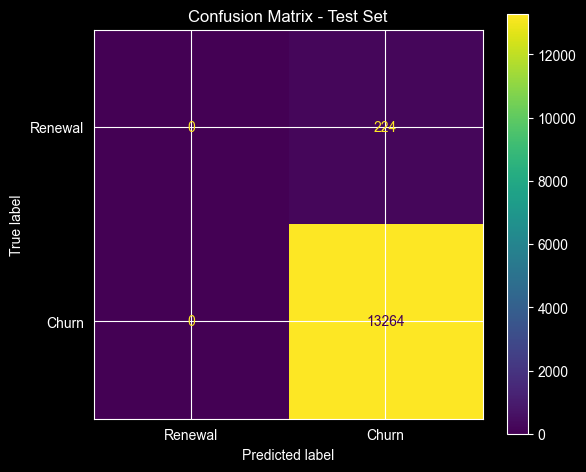

In [10]:
# Generate predictions on the held-out test set
# final_model was defined in Section 7 as the best estimator from RandomizedSearchCV
y_pred      = final_model.predict(X_test_fs)             # hard labels (0/1)
y_pred_prob = final_model.predict_proba(X_test_fs)[:, 1] # probability of class 1 (SAN)

# Print headline metrics
print('=' * 50)
print('FINAL TEST SET RESULTS')
print('=' * 50)

# ROC-AUC - primary ranking metric
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC  : {roc_auc:.4f}')
print()

# Classification report - precision, recall, F1 per class
print(classification_report(y_test, y_pred, target_names=["Renewal", 'Churn']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Renewal", 'Churn'],
    ax=ax,
)
ax.set_title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

## 9. Feature Importance

Extract and visualise the **top-20 most important features** according to the
tuned model. For tree-based models (HistGBM, Random Forest) the built-in
`feature_importances_` attribute is used. For Logistic Regression the absolute
value of the coefficients is used instead.


Computing permutation importance (this may take a moment)...
Importance method used: permutation


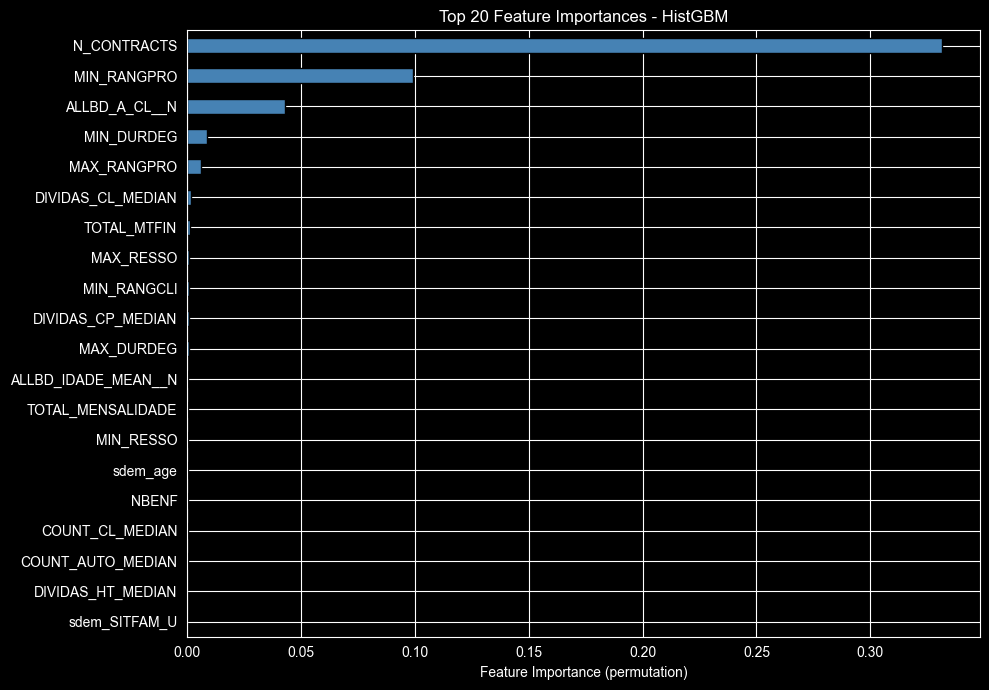


All 58 features ranked by importance:

N_CONTRACTS             0.331560
MIN_RANGPRO             0.099096
ALLBD_A_CL__N           0.043098
MIN_DURDEG              0.008661
MAX_RANGPRO             0.006307
DIVIDAS_CL_MEDIAN       0.001856
TOTAL_MTFIN             0.001191
MAX_RESSO               0.000982
MIN_RANGCLI             0.000959
DIVIDAS_CP_MEDIAN       0.000716
MAX_DURDEG              0.000650
ALLBD_IDADE_MEAN__N     0.000559
TOTAL_MENSALIDADE       0.000532
MIN_RESSO               0.000491
sdem_age                0.000331
NBENF                   0.000270
COUNT_CL_MEDIAN         0.000254
COUNT_AUTO_MEDIAN       0.000204
DIVIDAS_HT_MEDIAN       0.000146
sdem_SITFAM_U           0.000089
sdem_HABITAT_P          0.000075
sdem_HABITAT_A          0.000069
CSP_80.0                0.000062
sdem_SITFAM_S           0.000025
CSP_70.0                0.000018
ALLBD_A_CP__N           0.000009
sdem_SITFAM_X           0.000007
CSP_90.0                0.000004
CSP_91.0                0.000000
CSP

In [11]:
# Compute feature importances
# For tree-based models that expose .feature_importances_ (e.g. RF) we use the built-in attribute.  
# For models that do not (e.g. HistGBM in sklearn<1.6, Logistic Regression) we fall back to permutation importance, which
# measures how much the score drops when a feature is randomly shuffled.

if hasattr(final_model, 'feature_importances_'):
    # Built-in importance (mean decrease in impurity / gain)
    importances = final_model.feature_importances_
    importance_type = "built-in"
elif hasattr(final_model, 'coef_'):
    # Linear models - absolute coefficient values as an importance proxy
    importances = np.abs(final_model.coef_[0])
    importance_type = "coefficient-based"
else:
    # Permutation importance - model-agnostic, works for any estimator
    # Measures the drop in ROC-AUC when each feature is randomly shuffled
    print("Computing permutation importance (this may take a moment)...")
    perm_result = permutation_importance(
        final_model,
        X_test_fs,               # use test set for unbiased importance
        y_test,
        n_repeats=10,            # repeat the shuffle 10 times for stability
        scoring='roc_auc',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importances = perm_result.importances_mean
    importance_type = "permutation"

print(f"Importance method used: {importance_type}")

# Build a Series for easy sorting and plotting
feat_imp = pd.Series(importances, index=selected_features).sort_values(ascending=False)

# Display the top-20 features as a horizontal bar chart 
TOP_N = 20
top_features = feat_imp.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 7))
# sort ascending so the largest bar appears at the top of the horizontal chart
top_features.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel(f'Feature Importance ({importance_type})')
ax.set_title(f'Top {TOP_N} Feature Importances - {best_model_name}')
plt.tight_layout()
plt.show()

# Print the full ranking
print(f"\nAll {len(feat_imp)} features ranked by importance:\n")
print(feat_imp.to_string())

---

**Observations:**

- The feature importance chart highlights which variables are most predictive of early settlement.
- Review the top features to confirm they align with domain knowledge - any unexpected top-rankers could indicate remaining data-leakage issues or artefacts of the aggregation step.
- Features with near-zero importance may be candidates for removal in future iterations to further simplify the model.


---
## 10. Predictions about active clients

In [12]:
## 10. Predictions about active clients

mask_active = mask_active.drop(columns=drop_cols, errors='ignore')

X_active_processed = preprocessing_pipe.transform(mask_active)

# Retrieve feature names from the ColumnTransformer
feature_names = preprocessing_pipe.named_steps['ct'].get_feature_names_out()

X_active_df = pd.DataFrame(X_active_processed, columns=feature_names)

# Quick sanity checks
print(f'Active clients processed: {X_active_df.shape}')

remaining_nans = X_active_df.isna().sum().sum()
print(f'Any NaNs remaining: {remaining_nans}')

if remaining_nans > 0:
    print("WARNING: NaN values remain after preprocessing - check the pipeline!")

X_active_fs = X_active_df[selected_features]

# Generate predictions for active clients
y_active_pred = final_model.predict(X_active_fs)
y_active_prob = final_model.predict_proba(X_active_fs)[:, 1]

# Build output dataset with client ID and probability
results_active_df = pd.DataFrame({
    'CONTRIB':            mask_active.index,  # ou mask_active['CONTRIB'] se não for o index
    'Prob_Churn':           y_active_prob,
    'Pred_Label':         y_active_pred,
}).sort_values(by='Prob_Churn', ascending=False).reset_index(drop=True)

print('=' * 50)
print('ACTIVE CLIENTS - PREDICTED Churn')
print('=' * 50)
print(f'Total active clients scored: {len(results_active_df)}')
results_active_df

[ClientDataCleaner]
  Output shape     : (82407, 40)
  Columns removed  : —
  Dates converted  : —

[ClientOutlierHandler]
  Methods      : ('iqr', 'mod_z')  (min_votes=2)
  IQR k        : 1.5  |  Z threshold : 3.5
  Total flagged: 38767 cell(s) → set to NaN

    DIVIDAS_CP_MEDIAN                   7454 outlier(s)
    MIN_RESSO                           4424 outlier(s)
    MAX_RESSO                           4173 outlier(s)
    MEDIAN_RESSO                        4169 outlier(s)
    DIVIDAS_CL_MEDIAN                   3606 outlier(s)
    TOTAL_MTFIN                         3204 outlier(s)
    TOTAL_MTFINO                        3204 outlier(s)
    TOTAL_MENSALIDADE                   1969 outlier(s)
    ALLBD_N_Dossiers__N                 1820 outlier(s)
    ALLBD_N_events__N                   1820 outlier(s)
    COUNT_CL_MEDIAN                     756 outlier(s)
    COUNT_TOTAL_MEDIAN                  544 outlier(s)
    MAX_DURDEG                          445 outlier(s)
    MEDIAN_DURD

,CONTRIB,Prob_Churn,Pred_Label
0,148727,0.995666,1
1,1,0.995666,1
2,4,0.995666,1
3,5,0.995666,1
4,7,0.995666,1
...,...,...,...
82402,25887,0.641777,1
82403,9086,0.621267,1
82404,20363,0.615979,1
82405,127437,0.605352,1


---
## 11. Probabilities of settling early

In [13]:
# Combine probabilities with the true labels (and optionally their IDs if available)
results_df = pd.DataFrame({
    'True_Label': y_test,
    'Prob_Early_Settler': y_pred_prob
})

# Sort clients from highest probability of early settlement to lowest
results_df_sorted = results_df.sort_values(by='Prob_Early_Settler', ascending=False)

# Extract the top 10% most likely to settle early
top_10_cutoff = int(len(results_df_sorted) * 0.10)
top_10_percent = results_df_sorted.iloc[:top_10_cutoff]

top_10_percent.head(10)

,True_Label,Prob_Early_Settler
137195,1,0.995666
94528,1,0.995666
14478,1,0.995666
122063,1,0.995666
5010,1,0.995666
23384,1,0.995666
120559,1,0.995666
118794,1,0.995666
108588,1,0.995666
55006,1,0.995666


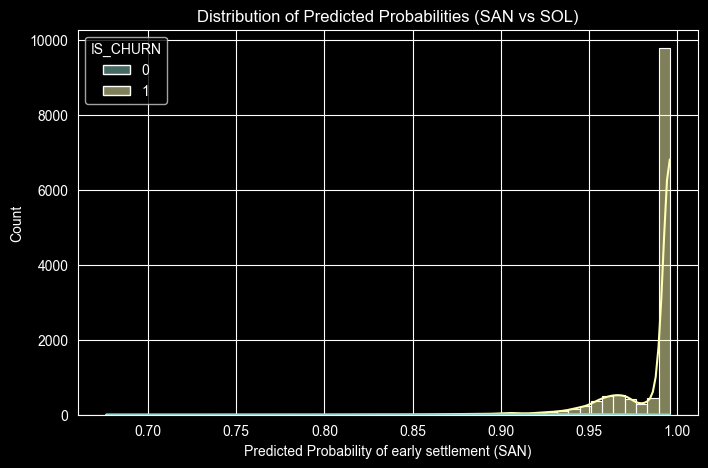

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(x=y_pred_prob, hue=y_test, bins=50, kde=True, common_norm=False)
plt.title('Distribution of Predicted Probabilities (SAN vs SOL)')
plt.xlabel('Predicted Probability of early settlement (SAN)')
plt.show()

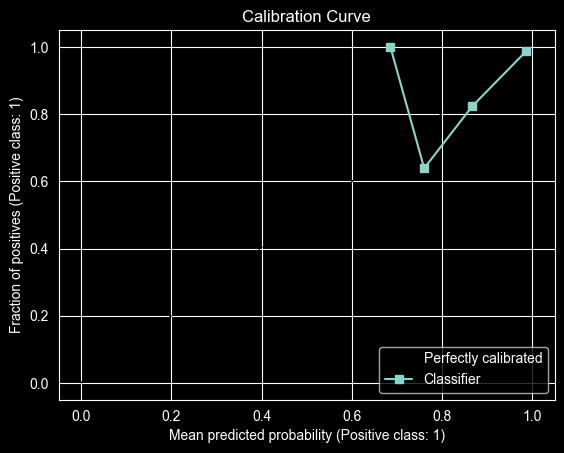

In [15]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test, y_pred_prob, n_bins=10)
plt.title('Calibration Curve')
plt.show()